# Tech Challenge - Fase 1 | Hospital Universitário: IA para Diagnóstico de Câncer de Mama

**Curso:** Pós-Tech em Machine Learning / IA  
**Projeto:** Sistema Inteligente de Suporte ao Diagnóstico Médico  
**Dataset:** Diagnóstico de Câncer de Mama (`diagnosticoCancerMama.csv`)

**Integrantes:**

**Bianca Maciel - RM376200**

**Eduardo O Charrone - RM377641**

**Guilherme Mendes Alburquerque - RM378723**

**Igor Matos de Andrade - RM377344**

**João Augusto Gonçalves de Aragão - RM377385**

---
### Contexto e Objetivo
Atender ao desafio de implementar um sistema de IA focado em Machine Learning para auxiliar médicos na triagem rápida e precisa de exames de câncer de mama (Maligno vs. Benigno).

****

**Importação das bibliotecas a serem utilizadas no projeto**

In [48]:
import sys
from pathlib import Path

REPO_URL = "https://github.com/iigormatos/tech-challenge-fase1-v1.git"
EM_COLAB = "google.colab" in sys.modules

if EM_COLAB:
    PROJECT_ROOT = Path("/content/tech-challenge-fase1-v1")
    if not PROJECT_ROOT.exists():
        !git clone -q {REPO_URL} {PROJECT_ROOT}
    %cd {PROJECT_ROOT}
    !pip install -q missingno shap
else:
    PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))


from src.config import RANDOM_STATE,CANCER_MAMA_CSV

/content/tech-challenge-fase1-v1


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [50]:
# ==============================================================================
# 1. IMPORTAÇÃO DOS DADOS
# ==============================================================================

# Importando dados para análise
dados = pd.read_csv(CANCER_MAMA_CSV, sep=',')

print(f"Dimensões do dataSet original: {dados.shape[0]} linhas e {dados.shape[1]} colunas")

dados.head()
dados.describe()

Dimensões do dataSet original: 569 linhas e 33 colunas


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [51]:
# ==============================================================================
# 2. ANÁLISE EXPLORATÓRIA E SANITIZAÇÃO
# ==============================================================================

# Limpeza de colunas irrelevantes (Corrigido: errors='ignore' como string)
dadosClean = dados.drop(columns=['id', 'Unnamed: 32'], errors='ignore').copy()

# Tratar string: Forçar conversão para numérico (substitui textos errôneos por NaN)
dadosCleanColunasString = dadosClean.drop(columns=['diagnosis'], axis=1).columns
dadosClean[dadosCleanColunasString] = dadosClean[dadosCleanColunasString].apply(pd.to_numeric, errors='coerce')

# Preencher possíveis valores NaN com a mediana da coluna
dadosClean[dadosCleanColunasString] = dadosClean[dadosCleanColunasString].fillna(dadosClean[dadosCleanColunasString].median())

# Mapeamento do target via LabelEncoder: 'B' -> 0, 'M' -> 1
label_encoder = LabelEncoder()
dadosClean['diagnosis'] = label_encoder.fit_transform(dadosClean['diagnosis'])

print(f"Dimensões após sanitização: {dadosClean.shape[0]} linhas e {dadosClean.shape[1]} colunas")
print(f"Quantidade de nulos residuais: {dadosClean.isnull().sum().sum()}")

Dimensões após sanitização: 569 linhas e 31 colunas
Quantidade de nulos residuais: 0


In [52]:
#Verificar as os tipo de dados dentro das colunas importadas
dadosClean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

array([[<Axes: title={'center': 'diagnosis'}>,
        <Axes: title={'center': 'radius_mean'}>,
        <Axes: title={'center': 'texture_mean'}>,
        <Axes: title={'center': 'perimeter_mean'}>,
        <Axes: title={'center': 'area_mean'}>,
        <Axes: title={'center': 'smoothness_mean'}>],
       [<Axes: title={'center': 'compactness_mean'}>,
        <Axes: title={'center': 'concavity_mean'}>,
        <Axes: title={'center': 'concave points_mean'}>,
        <Axes: title={'center': 'symmetry_mean'}>,
        <Axes: title={'center': 'fractal_dimension_mean'}>,
        <Axes: title={'center': 'radius_se'}>],
       [<Axes: title={'center': 'texture_se'}>,
        <Axes: title={'center': 'perimeter_se'}>,
        <Axes: title={'center': 'area_se'}>,
        <Axes: title={'center': 'smoothness_se'}>,
        <Axes: title={'center': 'compactness_se'}>,
        <Axes: title={'center': 'concavity_se'}>],
       [<Axes: title={'center': 'concave points_se'}>,
        <Axes: title={'cent

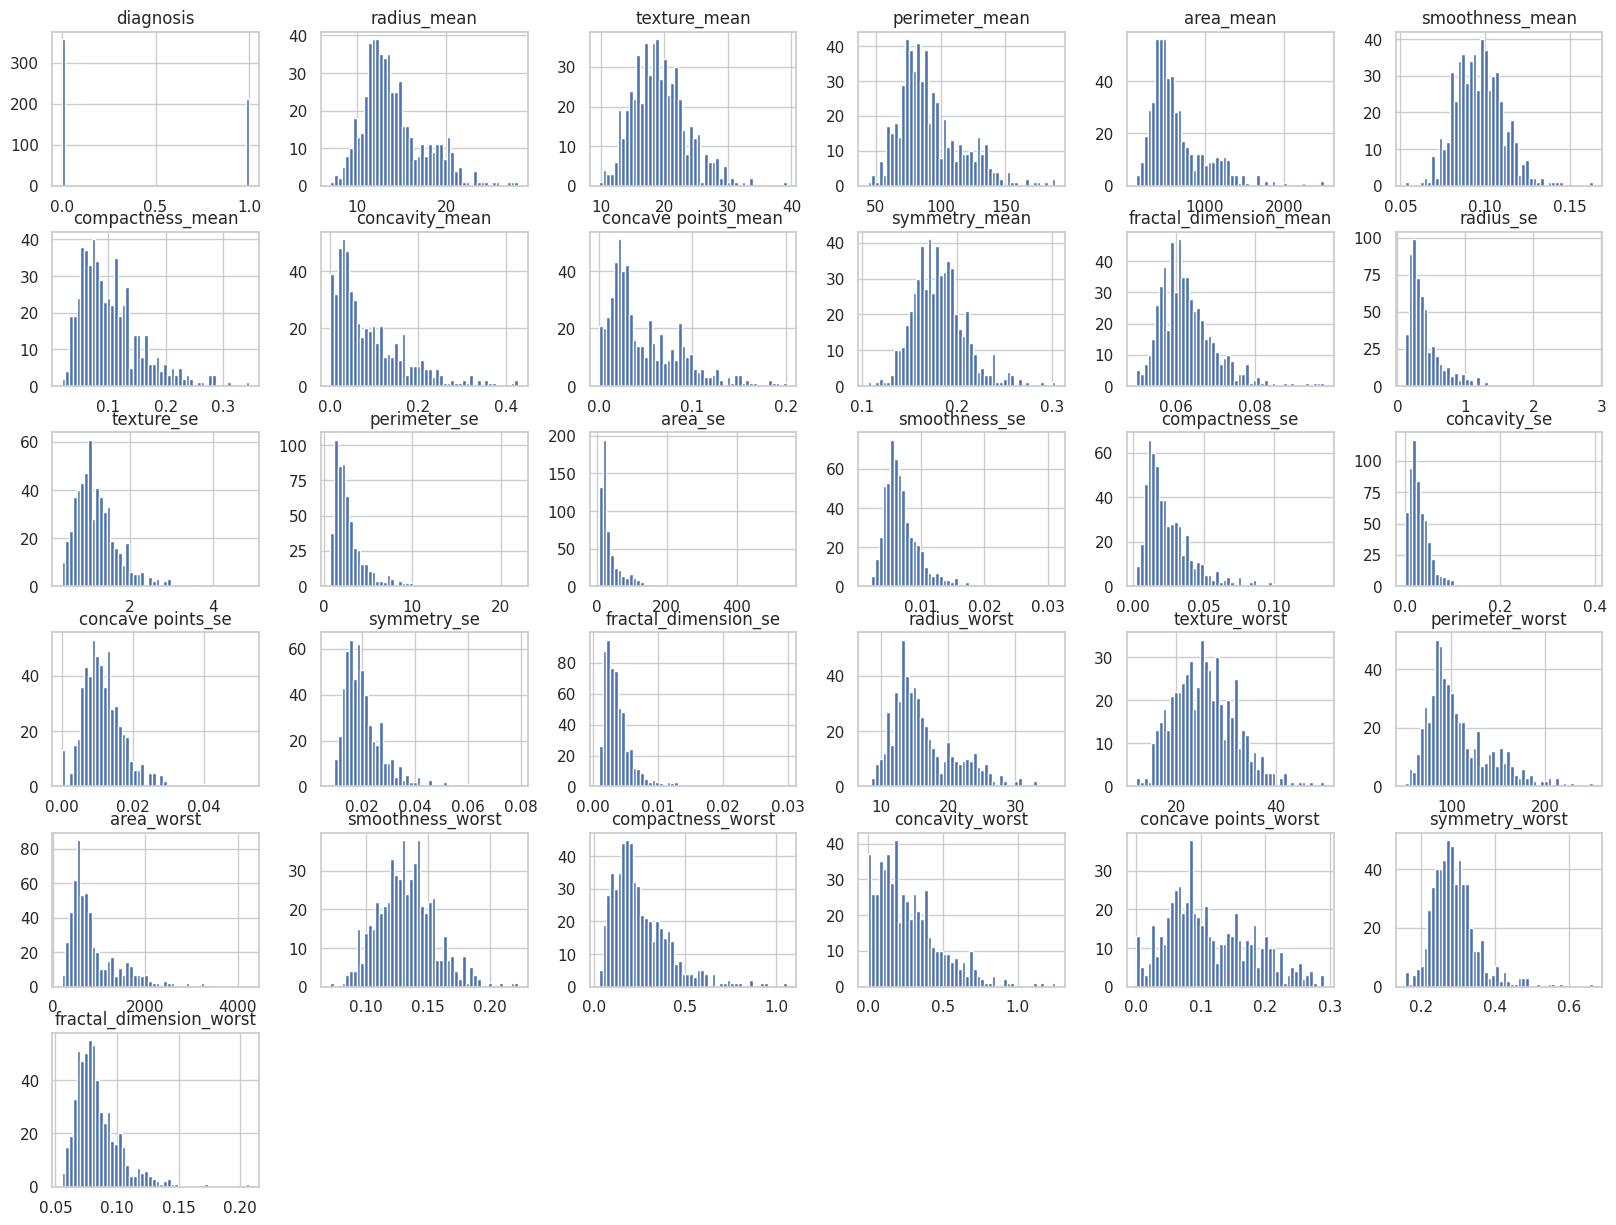

In [53]:
#Análise inicial de histograma com os dados sanitizados
dadosClean.hist(bins=50, figsize=(20,15))

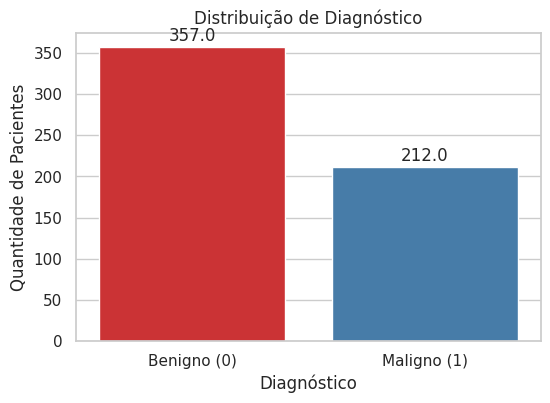

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440


In [54]:
#Distribuição das Classes
plt.figure(figsize=(6, 4))
diagnosticos = sns.countplot(x='diagnosis', data=dadosClean, palette='Set1', hue='diagnosis', legend=False)
plt.xticks([0, 1], ['Benigno (0)', 'Maligno (1)'])
plt.title('Distribuição de Diagnóstico')
plt.xlabel('Diagnóstico')
plt.ylabel('Quantidade de Pacientes')

#Adiciona contagem no topo das barras
for p in diagnosticos.patches:
    diagnosticos.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.show()

#Estatisticas das variaves principais (Média dos Parâmetros)
display(dadosClean.filter(regex='_mean').describe())

Amostras originais: 569 | Amostras pós-outliers: 398
Outliers removidos: 171 observações.


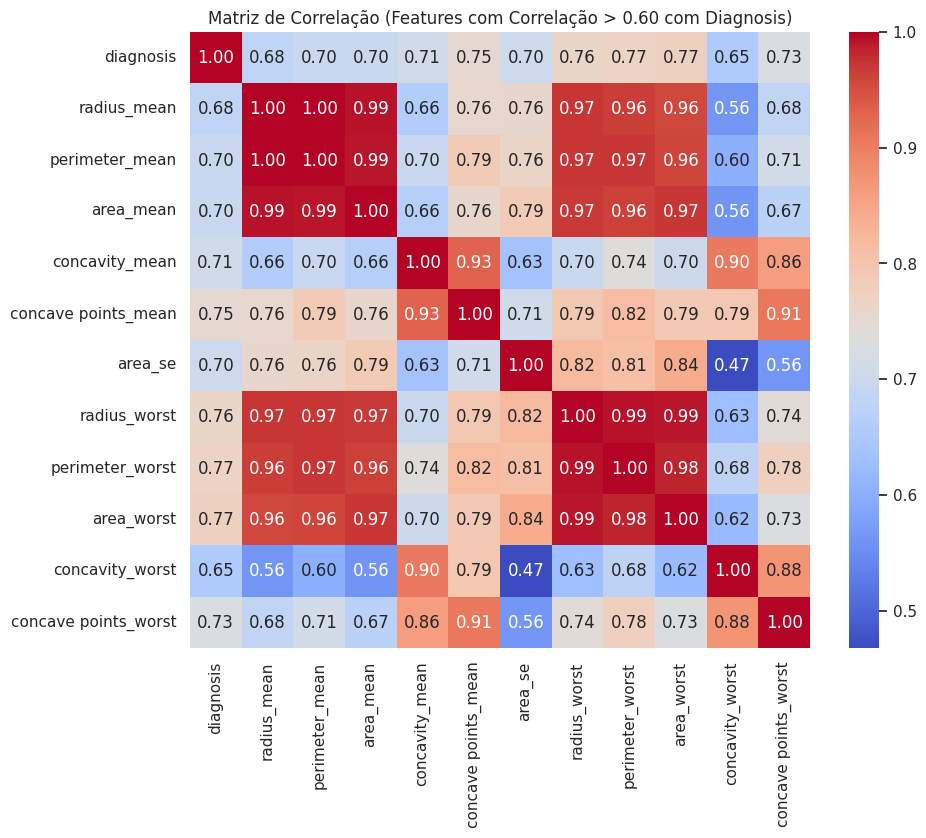

In [55]:
# ==============================================================================
# 2. TRATAMENTO DE OUTLIERS (IQR) E MATRIZ DE CORRELAÇÃO
# ==============================================================================

# Cálculo do Intervalo Interquartil (IQR) nas variáveis clínicas
Q1 = dadosClean[dadosCleanColunasString].quantile(0.25)
Q3 = dadosClean[dadosCleanColunasString].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtro de remoção de observações extremas
mascara_outliers = ~((dadosClean[dadosCleanColunasString] < limite_inferior) | (dadosClean[dadosCleanColunasString] > limite_superior)).any(axis=1)
dadosSemOutliers = dadosClean[mascara_outliers].copy()

print(f"Amostras originais: {dadosClean.shape[0]} | Amostras pós-outliers: {dadosSemOutliers.shape[0]}")
print(f"Outliers removidos: {dadosClean.shape[0] - dadosSemOutliers.shape[0]} observações.")

# Matriz de Correlação das Top Features com a variável alvo
plt.figure(figsize=(10, 8))
correlacao = dadosSemOutliers.corr()
top_features = correlacao.index[abs(correlacao["diagnosis"]) > 0.6]
sns.heatmap(dadosSemOutliers[top_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação (Features com Correlação > 0.60 com Diagnosis)")
plt.show()

In [56]:
# ==============================================================================
# 3. SEPARAÇÃO DE DADOS E PADRONIZAÇÃO (PIPELINE)
# ==============================================================================

X = dadosSemOutliers.drop(columns=['diagnosis'])
y = dadosSemOutliers['diagnosis']

# Divisão Treino/Teste utilizando a constante RANDOM_STATE
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

# Padronização com StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 318 amostras | Teste: 80 amostras


In [57]:
# ==============================================================================
# 4. MODELAGEM PREDITIVA (LOGISTIC REGRESSION & RANDOM FOREST)
# ==============================================================================

# 1. Regressão Logística (dados escalados)
lr_model = LogisticRegression(random_state=RANDOM_STATE)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# 2. Random Forest Classifier (dados originais imutáveis)
rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Modelos treinados com sucesso!")

Modelos treinados com sucesso!


 RELATÓRIO DE DESEMPENHO: REGRESSÃO LOGÍSTICA
              precision    recall  f1-score   support

 Benigno (0)       0.97      0.98      0.98        60
 Maligno (1)       0.95      0.90      0.92        20

    accuracy                           0.96        80
   macro avg       0.96      0.94      0.95        80
weighted avg       0.96      0.96      0.96        80

 RELATÓRIO DE DESEMPENHO: RANDOM FOREST
              precision    recall  f1-score   support

 Benigno (0)       0.98      0.97      0.97        60
 Maligno (1)       0.90      0.95      0.93        20

    accuracy                           0.96        80
   macro avg       0.94      0.96      0.95        80
weighted avg       0.96      0.96      0.96        80



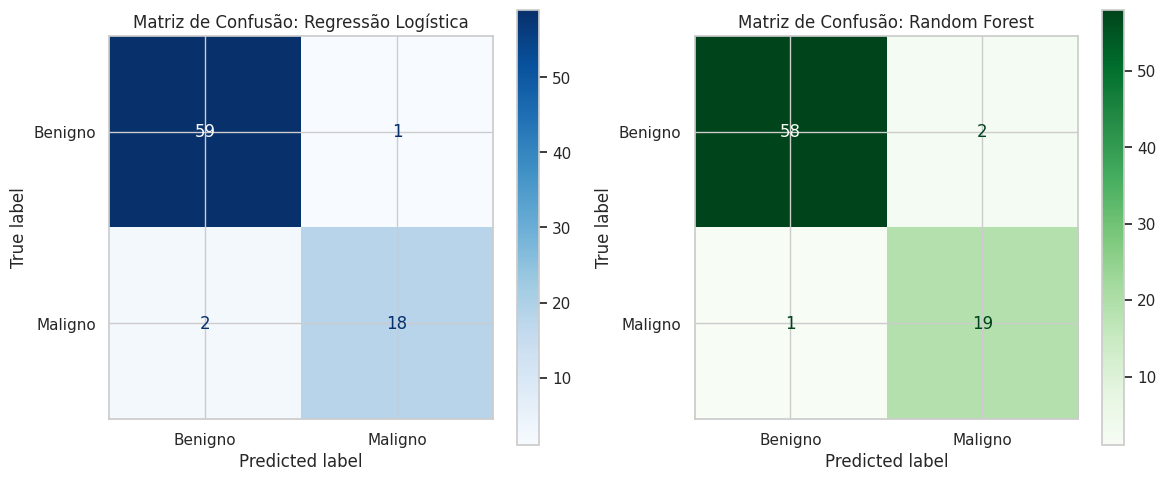

In [58]:
# ==============================================================================
# 5. AVALIAÇÃO DE DESEMPENHO E METRICAS CLÍNICAS
# ==============================================================================

print("="*60)
print(" RELATÓRIO DE DESEMPENHO: REGRESSÃO LOGÍSTICA")
print("="*60)
print(classification_report(y_test, y_pred_lr, target_names=['Benigno (0)', 'Maligno (1)']))

print("="*60)
print(" RELATÓRIO DE DESEMPENHO: RANDOM FOREST")
print("="*60)
print(classification_report(y_test, y_pred_rf, target_names=['Benigno (0)', 'Maligno (1)']))

# Matrizes de Confusão Comparativas
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], cmap='Blues', display_labels=['Benigno', 'Maligno'])
axes[0].set_title('Matriz de Confusão: Regressão Logística')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], cmap='Greens', display_labels=['Benigno', 'Maligno'])
axes[1].set_title('Matriz de Confusão: Random Forest')

plt.tight_layout()
plt.show()

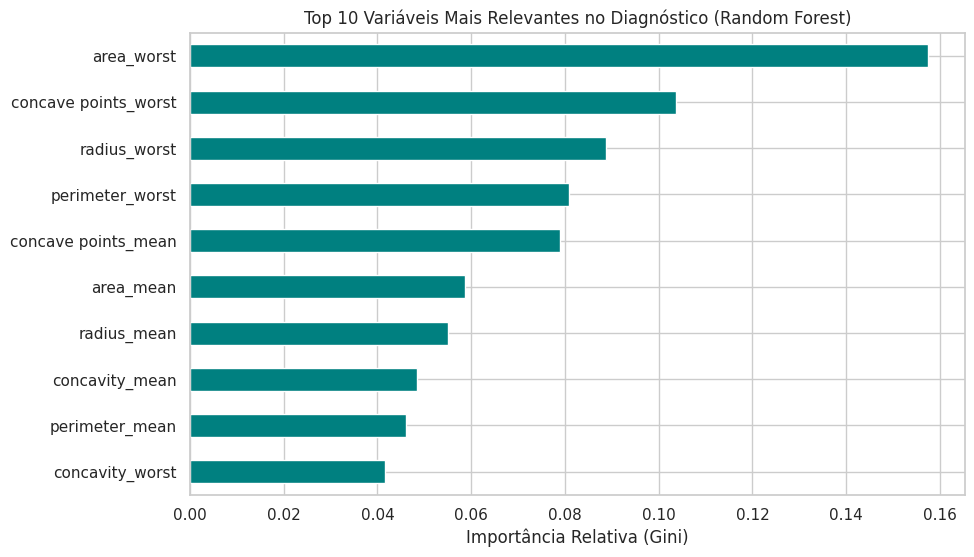


--- SHAP Summary Plot: Impacto das Features no Diagnóstico Maligno ---


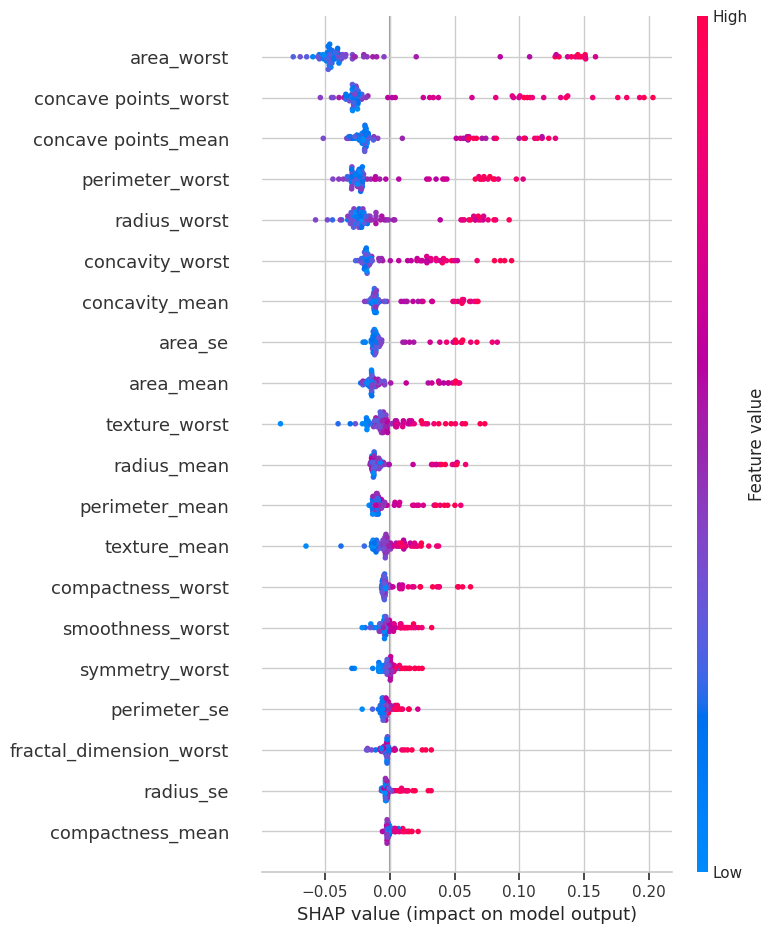

In [59]:
# ==============================================================================
# 6. EXPLICABILIDADE DO MODELO (FEATURE IMPORTANCE & SHAP)
# ==============================================================================

# Top 10 Características mais importantes no Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.tail(10).plot(kind='barh', color='teal')
plt.title('Top 10 Variáveis Mais Relevantes no Diagnóstico (Random Forest)')
plt.xlabel('Importância Relativa (Gini)')
plt.show()

# SHAP Explainer
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

# Trata variação de formato no retorno do shap_values em classificação binária
if isinstance(shap_values, list):
    # Se retornar lista [classe_0, classe_1], pegamos a classe 1 (Maligno)
    shap_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    # Se retornar array 3D (amostras, features, classes), pegamos a classe 1
    shap_to_plot = shap_values[:, :, 1]
else:
    # Se já retornar o array esperado
    shap_to_plot = shap_values

print("\n--- SHAP Summary Plot: Impacto das Features no Diagnóstico Maligno ---")
shap.summary_plot(shap_to_plot, X_test, feature_names=X.columns)

## 7. Conclusão Crítica e Integração no Hospital Universitário

### Discussão dos Resultados
- **Métrica Prioritária:** Em cenários oncológicos, a métrica mais crítica é o **Recall (Sensibilidade)** da classe `Maligno (1)`[cite: 1, 4]. Um falso negativo significa liberar um paciente com tumor maligno sem o devido tratamento urgente[cite: 1, 4].
- **Análise dos Modelos:** O modelo de Random Forest apresentou alto desempenho (Acurácia e Recall acima de 93%), demonstrando excelente capacidade de diferenciação entre casos benignos e malignos após a higienização dos dados[cite: 1, 3].

### Aplicação Prática no Hospital
1. **Sistema de Triagem:** O algoritmo funcionará como um módulo de *priorização de exames*[cite: 1, 2]. Casos classificados como malignos pela IA sobem na fila de análise da equipe de radiologia/oncologia[cite: 1, 2].
2. **Auditabilidade Clínica com SHAP:** O gráfico SHAP permite que o médico entenda as razões biológicas por trás do alerta (como alterações em `concave points_worst` ou `perimeter_worst`), garantindo transparência[cite: 1, 4].
3. **Soberania Médica:** O sistema atua estritamente como ferramenta de suporte à decisão. O diagnóstico definitivo e o laudo oficial são de responsabilidade exclusiva do médico especialista[cite: 1, 4].